# Cloud Height Algorithm Evaluation

First, let's define local data:

In [65]:
# Example usage with your file paths:
npz_output_path = 'outputs.npz'
sentinel2_safe_path = '/data/s2get/Sentinel-2/MSI/L1C/2025/04/10/S2B_MSIL1C_20250410T051649_N0511_R062_T42MYV_20250410T084204.SAFE'

In [66]:
products = {'S2C_MSIL1C_20250328T142931_N0511_R096_T22TES_20250328T175847' : 'T22TES.geojsonl',
            'S2C_MSIL1C_20250408T020711_N0511_R103_T51PWS_20250408T050426' : 'T51PWS.geojsonl',
            'S2B_MSIL1C_20250410T051649_N0511_R062_T42MYV_20250410T084204' : 'T42MYV.geojsonl'
           }

In [67]:
geojsonl_annotations_path = 'data/S2-Cloud-Heights/T42MYV.geojsonl'

and then prepare the data frames:

In [84]:
import geopandas as gpd
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xml.etree.ElementTree as ET
import rasterio
import math
import os
import json
from shapely.geometry import shape, Point
from scipy.interpolate import RegularGridInterpolator

def extract_line_endpoints(geometry):
    """
    Extracts the start and end coordinates of a line geometry,
    handling both LineString and MultiLineString.
    """
    if geometry.geom_type == 'LineString':
        start_coord = geometry.coords[0]
        end_coord = geometry.coords[-1]
    elif geometry.geom_type == 'MultiLineString':
        # Get the start of the first line and the end of the last line
        start_coord = geometry.geoms[0].coords[0]
        end_coord = geometry.geoms[-1].coords[-1]
    else:
        start_coord = None
        end_coord = None  # Or raise an exception, depending on how you want to handle other types
    return start_coord, end_coord


def extract_xy_from_coord(coord):
    """Extracts x and y from a coordinate tuple."""
    if coord:
        return coord[0], coord[1]
    else:
        return None, None


def process_geodataframe(gdf):
    """
    Processes a GeoDataFrame to extract start and end coordinates.
    """
    gdf['start_coord'], gdf['end_coord'] = zip(*gdf['geometry'].apply(extract_line_endpoints))
    gdf['start_x'], gdf['start_y'] = zip(*gdf['start_coord'].apply(extract_xy_from_coord))
    gdf['end_x'], gdf['end_y'] = zip(*gdf['end_coord'].apply(extract_xy_from_coord))
    return gdf

def geojsonl_to_geopandas(geojsonl_filepath):
    """
    Reads a GeoJSONL file and converts it into a geopandas GeoDataFrame.

    Args:
        geojsonl_filepath (str): Path to the GeoJSONL file.

    Returns:
        geopandas.GeoDataFrame: A GeoDataFrame containing the GeoJSON features.
    """

    features = []
    with open(geojsonl_filepath, 'r') as f:
        for line in f:
            try:
                feature = json.loads(line)
                features.append(feature)
            except json.JSONDecodeError as e:
                print(f"Error decoding JSON: {e}")

    # Extract geometry and properties
    geometries = [shape(feature['geometry']) for feature in features]
    properties = [feature['properties'] for feature in features]

    # Create a GeoDataFrame
    gdf = gpd.GeoDataFrame(properties, geometry=geometries)

    return gdf

def _find_tile_metadata_path(safe_path):
    """Finds the MTD_TL.xml file within a Sentinel-2 SAFE directory."""
    for root, dirs, files in os.walk(safe_path):
        if "GRANULE" in dirs:
            granule_dir = os.path.join(root, "GRANULE")
            for granule_root, _, granule_files in os.walk(granule_dir):
                if "MTD_TL.xml" in granule_files:
                    return os.path.join(granule_root, "MTD_TL.xml")
    raise FileNotFoundError("Sentinel-2 MTD_TL.xml file not found.")

def _extract_sun_angle_grid(root, angle_type, ns):
    """Extracts a sun angle grid (Zenith or Azimuth) from the XML."""

    angle_element = root.find(f".//Tile_Angles/Sun_Angles_Grid/{angle_type}", namespaces=ns)
    if angle_element is None:
        raise ValueError(f"Sun {angle_type} angles not found in MTD_TL.xml.")

    col_step_element = angle_element.find("COL_STEP", namespaces=ns)
    row_step_element = angle_element.find("ROW_STEP", namespaces=ns)
    values_list_elements = angle_element.findall("Values_List/VALUES", namespaces=ns)

    if col_step_element is None or row_step_element is None or not values_list_elements:
        raise ValueError(f"Incomplete sun {angle_type} angle grid information in MTD_TL.xml.")

    col_step = float(col_step_element.text)
    row_step = float(row_step_element.text)
    grid_values = []
    for values_element in values_list_elements:
        grid_values.append(list(map(float, values_element.text.split())))

    return {
        "col_step": col_step,
        "row_step": row_step,
        "values": np.array(grid_values)
    }

def _interpolate_sun_angles(angle_grid, x, y, transform):
    """Interpolates sun angles from the grid to given coordinates."""

    ulx, xres, _, uly, _, yres = transform
    col_coords = np.arange(0, angle_grid["values"].shape[1]) * angle_grid["col_step"] + ulx
    row_coords = uly - np.arange(0, angle_grid["values"].shape[0]) * angle_grid["row_step"]

    interp_func = RegularGridInterpolator((row_coords, col_coords), angle_grid["values"], bounds_error=False,
                                        fill_value=None)
    return interp_func((y, x))

def _get_metadata(metadata_path):
    """
    Extracts relevant metadata from the MTD_TL.xml file.

    Args:
        metadata_path (str): Path to the MTD_TL.xml file.

    Returns:
        dict: A dictionary containing CRS, transform, and sun angle grids.
    """
    tree = ET.parse(metadata_path)
    root = tree.getroot()
    ns = {'n1': 'https://psd-15.sentinel2.eo.esa.int/PSD/S2_PDI_Level-1C_Tile_Metadata.xsd'}

    # Extract CRS
    horizontal_cs_code_element = root.find(".//n1:Geometric_Info/Tile_Geocoding/HORIZONTAL_CS_CODE",
                                            namespaces=ns)
    if horizontal_cs_code_element is not None:
        utm_crs = horizontal_cs_code_element.text
    else:
        raise ValueError("UTM CRS (HORIZONTAL_CS_CODE) not found in MTD_TL.xml.")

    # Extract transform (geotransform) parameters
    # Extract transform (geotransform) parameters
    ulx_element = root.find(".//n1:Geometric_Info/Tile_Geocoding/Geoposition[@resolution='10']/ULX", namespaces=ns)
    uly_element = root.find(".//n1:Geometric_Info/Tile_Geocoding/Geoposition[@resolution='10']/ULY", namespaces=ns)
    xdim_element = root.find(".//n1:Geometric_Info/Tile_Geocoding/Geoposition[@resolution='10']/XDIM", namespaces=ns)
    ydim_element = root.find(".//n1:Geometric_Info/Tile_Geocoding/Geoposition[@resolution='10']/YDIM", namespaces=ns)

    if ulx_element is not None and uly_element is not None and xdim_element is not None and ydim_element is not None:
        ulx = float(ulx_element.text)
        uly = float(uly_element.text)
        xdim = float(xdim_element.text)
        ydim = float(ydim_element.text)
        transform = (ulx, xdim, 0, uly, 0, ydim)  # GDAL geotransform
    else:
        raise ValueError("Geotransform information not found in MTD_TL.xml.")

    # Extract sun angle grids
    sun_zenith_grid = _extract_sun_angle_grid(root, "Zenith", ns)
    sun_azimuth_grid = _extract_sun_angle_grid(root, "Azimuth", ns)

    return {
        "utm_crs": utm_crs,
        "transform": transform,
        "sun_zenith_grid": sun_zenith_grid,
        "sun_azimuth_grid": sun_azimuth_grid
    }

def _load_prediction_data(npz_output_path, transform, crs):
    """
    Loads prediction data from an .npz file and transforms coordinates to a GeoDataFrame.

    Args:
        npz_output_path (str): Path to the .npz file.
        transform (tuple): GDAL geotransform tuple.
        crs (str, optional): The CRS to assign to the GeoDataFrame. Defaults to "EPSG:32742" (UTM zone).

    Returns:
        gpd.GeoDataFrame: A GeoDataFrame with 'geometry' (Point), 'utm_x', 'utm_y', and 'height' columns.
    """
    npz_data = np.load(npz_output_path)
    heights = npz_data['heights']
    coords = npz_data['coords']

    ulx, xres, x_rotation, uly, y_rotation, yres = transform  # Corrected unpacking
    utm_x = ulx + coords[:, 0] * xres
    utm_y = uly + coords[:, 1] * yres

    geometry = [Point(x, y) for x, y in zip(utm_x, utm_y)]

    prediction_df = pd.DataFrame({
        'utm_x': utm_x,
        'utm_y': utm_y,
        'height': heights
    })

    prediction_gdf = gpd.GeoDataFrame(prediction_df, geometry=geometry, crs=crs)

    return prediction_gdf


def _load_ground_truth_data(geojsonl_annotations_path, utm_crs):
    """
    Loads ground truth data from a GeoJSONL file and reprojects it to the specified UTM CRS.

    Args:
        geojsonl_annotations_path (str): Path to the GeoJSONL file.
        utm_crs (str): The target UTM CRS (e.g., "EPSG:32742").

    Returns:
        gpd.GeoDataFrame: A GeoDataFrame with the ground truth data in the specified UTM CRS.
    """
    gdf = geojsonl_to_geopandas(geojsonl_annotations_path).explode() # explode converts multilinestring to linestring

    # 1. Check if gdf already has a CRS
    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")  # ASSUME WGS 84 if no CRS is present
        
    gdf = gdf.to_crs(utm_crs)
    return gdf

In [85]:
# Stage I: Data Prep
# 0. Read all necessary information from the scene metadata
metadata_path = _find_tile_metadata_path(sentinel2_safe_path)
metadata = _get_metadata(metadata_path)

# 1. Read the output of the algorithm and map the points to the UTM of the scene
prediction_df = _load_prediction_data(npz_output_path, metadata['transform'], metadata['utm_crs'])

# 2. Read the geometry of the ground truth file (geojson) and map it to the UTM of the scene in gt_df dataframe
gt_df = _load_ground_truth_data(geojsonl_annotations_path, metadata['utm_crs'])
gt_df = process_geodataframe(gt_df)

gt_df.head()

/tmp/ipykernel_2199705/2468523480.py:217: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  gdf = geojsonl_to_geopandas(geojsonl_annotations_path).explode() # explode converts multilinestring to linestring


,,id,geometry,start_coord,end_coord,start_x,start_y,end_x,end_y
0,0,None,"LINESTRING (758119.866 9468477.057, 757756.345...","(758119.8660164959, 9468477.05709972)","(757756.3451034456, 9468265.000111388)",758119.866016,9.468477e+06,757756.345103,9.468265e+06
1,0,None,"LINESTRING (757332.236 9464254.131, 757017.183...","(757332.235564261, 9464254.13058156)","(757017.1833132491, 9464042.080780609)",757332.235564,9.464254e+06,757017.183313,9.464042e+06
2,0,None,"LINESTRING (756859.658 9465714.288, 756405.251...","(756859.6584481084, 9465714.288061246)","(756405.2506834574, 9465435.578656416)",756859.658448,9.465714e+06,756405.250683,9.465436e+06
3,0,None,"LINESTRING (760055.628 9463627.056, 759683.007...","(760055.6275442586, 9463627.0560528)","(759683.0067874913, 9463393.796050139)",760055.627544,9.463627e+06,759683.006787,9.463394e+06
4,0,None,"LINESTRING (765329.725 9459982.752, 764848.056...","(765329.7252159184, 9459982.751536718)","(764848.0559202726, 9459676.786976278)",765329.725216,9.459983e+06,764848.055920,9.459677e+06


The script also read sun angle grids from metadata:

Text(0.5, 1.0, 'Sun Azimuth')

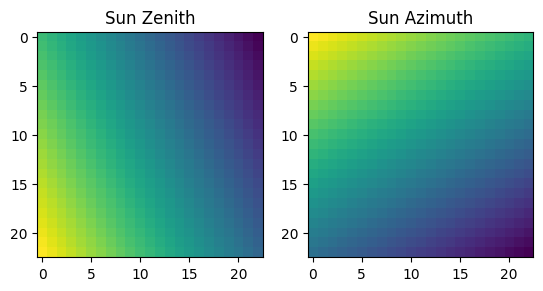

In [77]:
import matplotlib.pyplot as plt

plt.subplot(121)
plt.imshow(metadata['sun_zenith_grid']['values'])
plt.title('Sun Zenith')
plt.subplot(122)
plt.imshow(metadata['sun_azimuth_grid']['values'])
plt.title('Sun Azimuth')

In [102]:
def _determine_cloud_top(gdf):
    """Determines cloud top coordinates using sun azimuth."""
    cloud_top_x = []
    cloud_top_y = []

    for _, row in gdf.iterrows():
        start_x, start_y, end_x, end_y = row['start_x'], row['start_y'], row['end_x'], row['end_y']

        # Calculate line direction
        line_azimuth = math.degrees(math.atan2(end_y - start_y, end_x - start_x))

        # Normalize azimuth angles to 0-360 range
        sun_azimuth = row['sun_azimuth']
        sun_azimuth_norm = (sun_azimuth + 360) % 360
        line_azimuth_norm = (line_azimuth + 360) % 360

        # Determine if line direction is opposite to sun azimuth
        angle_diff = abs(sun_azimuth_norm - line_azimuth_norm)
        if angle_diff > 180:
            angle_diff = 360 - angle_diff

        if angle_diff < 90:  # Adjust tolerance as needed
            cloud_top_x.append(end_x)
            cloud_top_y.append(end_y)
        else:
            cloud_top_x.append(start_x)
            cloud_top_y.append(start_y)

    return cloud_top_x, cloud_top_y

def _calculate_ground_truth_heights(gdf, scene_metadata):
    """
    Calculates cloud heights for the ground truth lines based on sun angles.

    Args:
        gdf (gpd.GeoDataFrame): GeoDataFrame containing ground truth line geometries.
        sun_zenith_grid (dict): Dictionary containing sun zenith angle grid information.
        transform (tuple): GDAL geotransform tuple.

    Returns:
        gpd.GeoDataFrame: GeoDataFrame with an added 'height' column.
    """
    sun_zenith_grid = metadata['sun_zenith_grid']
    sun_azimuth_grid = metadata['sun_azimuth_grid']
    transform = metadata['transform']
    

    gdf['length'] = gdf['geometry'].length

    gdf['sun_zenith'] = _interpolate_sun_angles(sun_zenith_grid, gdf['start_x'], gdf['start_y'], transform)
    gdf['sun_elevation'] = 90 - gdf['sun_zenith']
    gdf['sun_azimuth'] = _interpolate_sun_angles(sun_azimuth_grid, gdf['start_x'], gdf['start_y'], transform)
    gdf['height'] = gdf['length'] * np.tan(np.radians(gdf['sun_elevation']))

    # Determine cloud top using sun azimuth
    gdf['cloud_top_x'], gdf['cloud_top_y'] = _determine_cloud_top(gdf)

    return gdf

In [103]:
# 3. Create another column ('height') to gt_df that estimates height based on each line and sun angle information
gt_df = _calculate_ground_truth_heights(gt_df, metadata)

gt_df

,,id,geometry,start_coord,end_coord,start_x,start_y,end_x,end_y,length,sun_zenith,sun_elevation,height,sun_azimuth,cloud_top_x,cloud_top_y
0,0,None,"LINESTRING (758119.866 9468477.057, 757756.345...","(758119.8660164959, 9468477.05709972)","(757756.3451034456, 9468265.000111388)",758119.866016,9.468477e+06,757756.345103,9.468265e+06,420.851067,27.073130,62.926870,823.367050,61.754962,758119.866016,9.468477e+06
1,0,None,"LINESTRING (757332.236 9464254.131, 757017.183...","(757332.235564261, 9464254.13058156)","(757017.1833132491, 9464042.080780609)",757332.235564,9.464254e+06,757017.183313,9.464042e+06,379.767085,27.094998,62.905002,742.289741,61.693533,757332.235564,9.464254e+06
2,0,None,"LINESTRING (756859.658 9465714.288, 756405.251...","(756859.6584481084, 9465714.288061246)","(756405.2506834574, 9465435.578656416)",756859.658448,9.465714e+06,756405.250683,9.465436e+06,533.071617,27.093262,62.906738,1042.015439,61.721408,756859.658448,9.465714e+06
3,0,None,"LINESTRING (760055.628 9463627.056, 759683.007...","(760055.6275442586, 9463627.0560528)","(759683.0067874913, 9463393.796050139)",760055.627544,9.463627e+06,759683.006787,9.463394e+06,439.609437,27.076034,62.923966,859.958962,61.659078,760055.627544,9.463627e+06
4,0,None,"LINESTRING (765329.725 9459982.752, 764848.056...","(765329.7252159184, 9459982.751536718)","(764848.0559202726, 9459676.786976278)",765329.725216,9.459983e+06,764848.055920,9.459677e+06,570.630899,27.048448,62.951552,1117.588996,61.552676,765329.725216,9.459983e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,0,None,"LINESTRING (729277.394 9407758.221, 728925.993...","(729277.3941785395, 9407758.220622726)","(728925.9934399503, 9407500.72696922)",729277.394179,9.407758e+06,728925.993440,9.407501e+06,435.643731,27.526890,62.473110,835.905762,61.040229,729277.394179,9.407758e+06
99,0,None,"LINESTRING (729422.807 9409615.210, 727544.610...","(729422.8068885967, 9409615.210413618)","(727544.6103925284, 9408355.002672527)",729422.806889,9.409615e+06,727544.610393,9.408355e+06,2261.801412,27.518633,62.481367,4341.432387,61.068325,729422.806889,9.409615e+06
100,0,None,"LINESTRING (728668.492 9411178.354, 728217.119...","(728668.491842238, 9411178.353990542)","(728217.1191799918, 9410860.271494394)",728668.491842,9.411178e+06,728217.119180,9.410860e+06,552.189962,27.518546,62.481454,1059.909250,61.099889,728668.491842,9.411178e+06
101,0,None,"LINESTRING (727802.098 9411675.168, 727347.696...","(727802.0980008455, 9411675.168126497)","(727347.6963630684, 9411375.26371239)",727802.098001,9.411675e+06,727347.696363,9.411375e+06,544.447891,27.523399,62.476601,1044.832647,61.115558,727802.098001,9.411675e+06


In [104]:
prediction_df

,utm_x,utm_y,height,geometry
0,7.034913e+05,9.421114e+06,1600,POINT (703491.263 9421114.102)
1,7.386420e+05,9.489455e+06,0,POINT (738642.036 9489454.823)
2,7.364776e+05,9.479692e+06,800,POINT (736477.640 9479691.863)
3,7.191625e+05,9.401588e+06,1200,POINT (719162.471 9401588.182)
4,7.169981e+05,9.391825e+06,2000,POINT (716998.075 9391825.222)
...,...,...,...,...
3542,1.797665e+06,8.537801e+06,0,POINT (1797665.358 8537800.527)
3543,1.780350e+06,8.459697e+06,11600,POINT (1780350.189 8459696.846)
3544,1.771693e+06,8.420645e+06,800,POINT (1771692.604 8420645.006)
3545,1.769528e+06,8.410882e+06,1200,POINT (1769528.208 8410882.046)


## Evaluation:
Finally, we can find the closest points in the two data frames and apply performance metrics based on matched data points:

In [105]:
def _match_predictions_to_ground_truth(prediction_df, gt_df):
    """
    Matches predicted cloud heights to the nearest ground truth cloud top locations.

    Args:
        prediction_df (gpd.GeoDataFrame): GeoDataFrame containing predicted cloud heights and coordinates (geometry column).
        gt_df (gpd.GeoDataFrame): GeoDataFrame containing ground truth annotations with 'cloud_top_x', 'cloud_top_y', and 'height'.

    Returns:
        gpd.GeoDataFrame: GeoDataFrame with matched predicted and ground truth heights, and a 'geometry' column for cloud top points.
    """

    predicted_heights = []
    ground_truth_heights = []
    cloud_top_geometries = []  # List to store cloud top geometries

    # Create GeoSeries of cloud top points for distance calculations
    gt_cloud_top_points = gpd.GeoSeries(
        [Point(x, y) for x, y in zip(gt_df['cloud_top_x'], gt_df['cloud_top_y'])],
        crs=gt_df.crs  # Ensure the same CRS as prediction_df
    )

    for i, gt_point in enumerate(gt_cloud_top_points):
        # Calculate distances to predicted points
        distances = prediction_df['geometry'].distance(gt_point)
        nearest_index = np.argmin(distances)

        # Append predicted and ground truth heights
        predicted_heights.append(prediction_df['height'].iloc[nearest_index])
        ground_truth_heights.append(gt_df['height'].iloc[i])

        # Append the cloud top geometry
        cloud_top_geometries.append(gt_point)

    # Create the output GeoDataFrame
    matched_data = pd.DataFrame({
        'predicted_height': predicted_heights,
        'ground_truth_height': ground_truth_heights
    })
    matched_gdf = gpd.GeoDataFrame(matched_data, geometry=cloud_top_geometries, crs=gt_df.crs)

    return matched_gdf


def _compute_performance_metrics(matched_data):
    """
    Computes regression performance metrics.

    Args:
        matched_data (pd.DataFrame): DataFrame with matched predicted and ground truth heights.

    Returns:
        dict: A dictionary containing regression performance metrics.
    """

    mse = mean_squared_error(matched_data['ground_truth_height'], matched_data['predicted_height'])
    mae = mean_absolute_error(matched_data['ground_truth_height'], matched_data['predicted_height'])
    r2 = r2_score(matched_data['ground_truth_height'], matched_data['predicted_height'])

    return {
        'mse': mse,
        'mae': mae,
        'r2': r2,
        'ground_truth_heights': matched_data['ground_truth_height'].tolist(),
        'predicted_heights': matched_data['predicted_height'].tolist()
    }


def validate_cloud_height(npz_output_path, geojsonl_annotations_path, sentinel2_safe_path):
    """
    Validates cloud height algorithm output against GeoJSONL annotations.

    Args:
        npz_output_path (str): Path to the algorithm output .npz file (coordinates, height).
        geojsonl_annotations_path (str): Path to the QGIS annotations GeoJSONL file.
        sentinel2_safe_path (str): Path to the Sentinel-2 SAFE directory.

    Returns:
        dict: A dictionary containing regression performance metrics.
    """

    # Stage I: Data Prep
    # 0. Read all necessary information from the scene metadata
    metadata_path = _find_tile_metadata_path(sentinel2_safe_path)
    metadata = _get_metadata(metadata_path)

    # 1. Read the output of the algorithm and map the points to the UTM of the scene
    prediction_df = _load_prediction_data(npz_output_path, metadata['transform'])

    # 2. Read the geometry of the ground truth file (geojson) and map it to the UTM of the scene in gt_df dataframe
    gt_df = _load_ground_truth_data(geojsonl_annotations_path, metadata['utm_crs'])

    # 3. Create another column ('height') to gt_df that estimates height based on each line and sun angle information
    gt_df = _calculate_ground_truth_heights(gt_df, metadata['sun_zenith_grid'], metadata['transform'])

    # Stage II: Validation
    # 1. Match. points from gt_df to the closest points in prediction_df
    matched_data = _match_predictions_to_ground_truth(prediction_df, gt_df)

    # 2. Compute the performance metrics on existing data
    results = _compute_performance_metrics(matched_data)

    return results

In [110]:
# Stage II: Validation
# 1. Match. points from gt_df to the closest points in prediction_df
matched_data = _match_predictions_to_ground_truth(prediction_df, gt_df)

# 2. Compute the performance metrics on existing data
results = _compute_performance_metrics(matched_data)

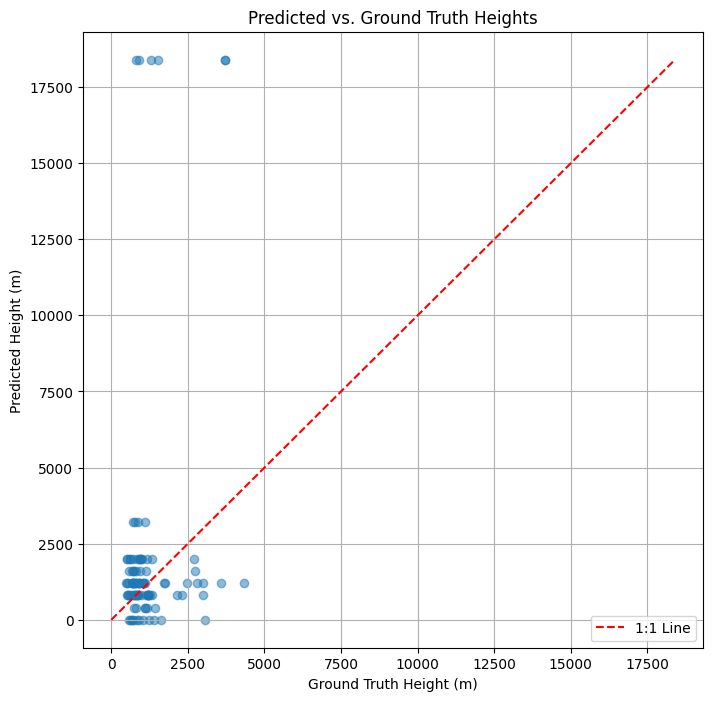

In [112]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_correlation_scatter_with_metrics(matched_data, title="Predicted vs. Ground Truth Heights"):
    """
    Generates a correlation scatter plot of predicted vs. ground truth heights
    and displays MSE, MAE, and R2 on the plot.

    Args:
        matched_data (pd.DataFrame): DataFrame with 'predicted_height' and 'ground_truth_height' columns.
        title (str, optional): Title of the plot. Defaults to "Predicted vs. Ground Truth Heights".

    Returns:
        None: Displays the plot.
    """

    mse = mean_squared_error(matched_data['ground_truth_height'], matched_data['predicted_height'])
    mae = mean_absolute_error(matched_data['ground_truth_height'], matched_data['predicted_height'])
    r2 = r2_score(matched_data['ground_truth_height'], matched_data['predicted_height'])

    plt.figure(figsize=(8, 8))
    plt.scatter(matched_data['ground_truth_height'], matched_data['predicted_height'], alpha=0.5)
    plt.xlabel("Ground Truth Height (m)")
    plt.ylabel("Predicted Height (m)")
    plt.title(title)
    plt.grid(True)

    min_val = min(matched_data['ground_truth_height'].min(), matched_data['predicted_height'].min())
    max_val = max(matched_data['ground_truth_height'].max(), matched_data['predicted_height'].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="1:1 Line")
    plt.legend()

    # Create text to display metrics
    metrics_text = f"MSE = {mse:.2f} m\nMAE = {mae:.2f} m\nR2 = {r2:.2f}"
    plt.text(0.05, 0.95, metrics_text, transform=plt.gca().transAxes, verticalalignment='top')  # Position text in the top-left corner

    plt.show()

plot_correlation_scatter(matched_data)

AttributeError: module 'matplotlib.pyplot' has no attribute 'hold'

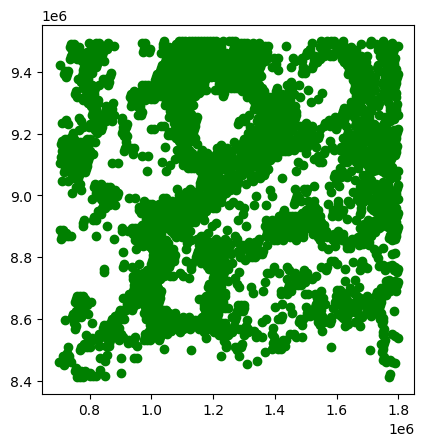

In [97]:
prediction_df.plot(color='green')
plt.hold('on')
gt_df.plot(color='red')